In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['font.size'] = 12

In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.2860),(0.3530))

])

In [6]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [7]:
train_dataset = torchvision.datasets.FashionMNIST(root = './data',
                                                  train = True,
                                                  download = True,
                                                  transform = transform)
test_dataset = torchvision.datasets.FashionMNIST(root = './data',
                                                 train = False,
                                                 download = True,
                                                 transform = transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.7MB/s]


In [10]:
batch_size = 64

In [11]:
train_loader = DataLoader(train_dataset,
                          batch_size = batch_size,
                          shuffle = True,
                          num_workers = 2,
                          pin_memory = True)



print('----train_datast Statistics---')
print(f"train_datast samples {len(train_dataset)}")
print(f"num of classes {len(class_names)}")
print(f"train_datast samples {len(train_dataset)}")
print(f"training batchess {len(train_loader)}")


----train_datast Statistics---
train_datast samples 60000
num of classes 10
train_datast samples 60000
training batchess 938


In [12]:
test_loader = DataLoader(test_dataset,
                         batch_size = batch_size,
                         shuffle = False,
                         num_workers = 2,
                         pin_memory = True)

print('----train_datast Statistics---')
print(f"train_datast samples {len(test_dataset)}")
print(f"num of classes {len(class_names)}")
print(f"train_datast samples {len(test_dataset)}")
print(f"training batchess {len(test_loader)}")

----train_datast Statistics---
train_datast samples 10000
num of classes 10
train_datast samples 10000
training batchess 157


In [13]:
sample_batch = next(iter(train_loader))

images,labels = sample_batch


print(f"-------Batch Analysis--------")

print(f"image tensor shape {images.shape}")
print(f"labels tensor shape {labels.shape}")
print(f"image tensor datatype {images.dtype}")
print(f"labels tensor datatype {labels.dtype}")


print(f"image value range {images.min():.3f},{images.max():.3f}")





input_size = images[0].numel()
print(f"input size for mlp: {input_size})")

-------Batch Analysis--------
image tensor shape torch.Size([64, 1, 28, 28])
labels tensor shape torch.Size([64])
image tensor datatype torch.float32
labels tensor datatype torch.int64
image value range -0.810,2.023
input size for mlp: 784)


In [14]:
unique_labels,counts = torch.unique(labels,return_counts = True)

for label,count in zip(unique_labels,counts):
  print(f"{class_names[label]}:{count.item()} samples")

T-shirt/top:7 samples
Trouser:1 samples
Pullover:9 samples
Dress:11 samples
Coat:9 samples
Sandal:7 samples
Shirt:4 samples
Sneaker:5 samples
Bag:5 samples
Ankle boot:6 samples


-----visualization-----


<Figure size 1600x1200 with 0 Axes>

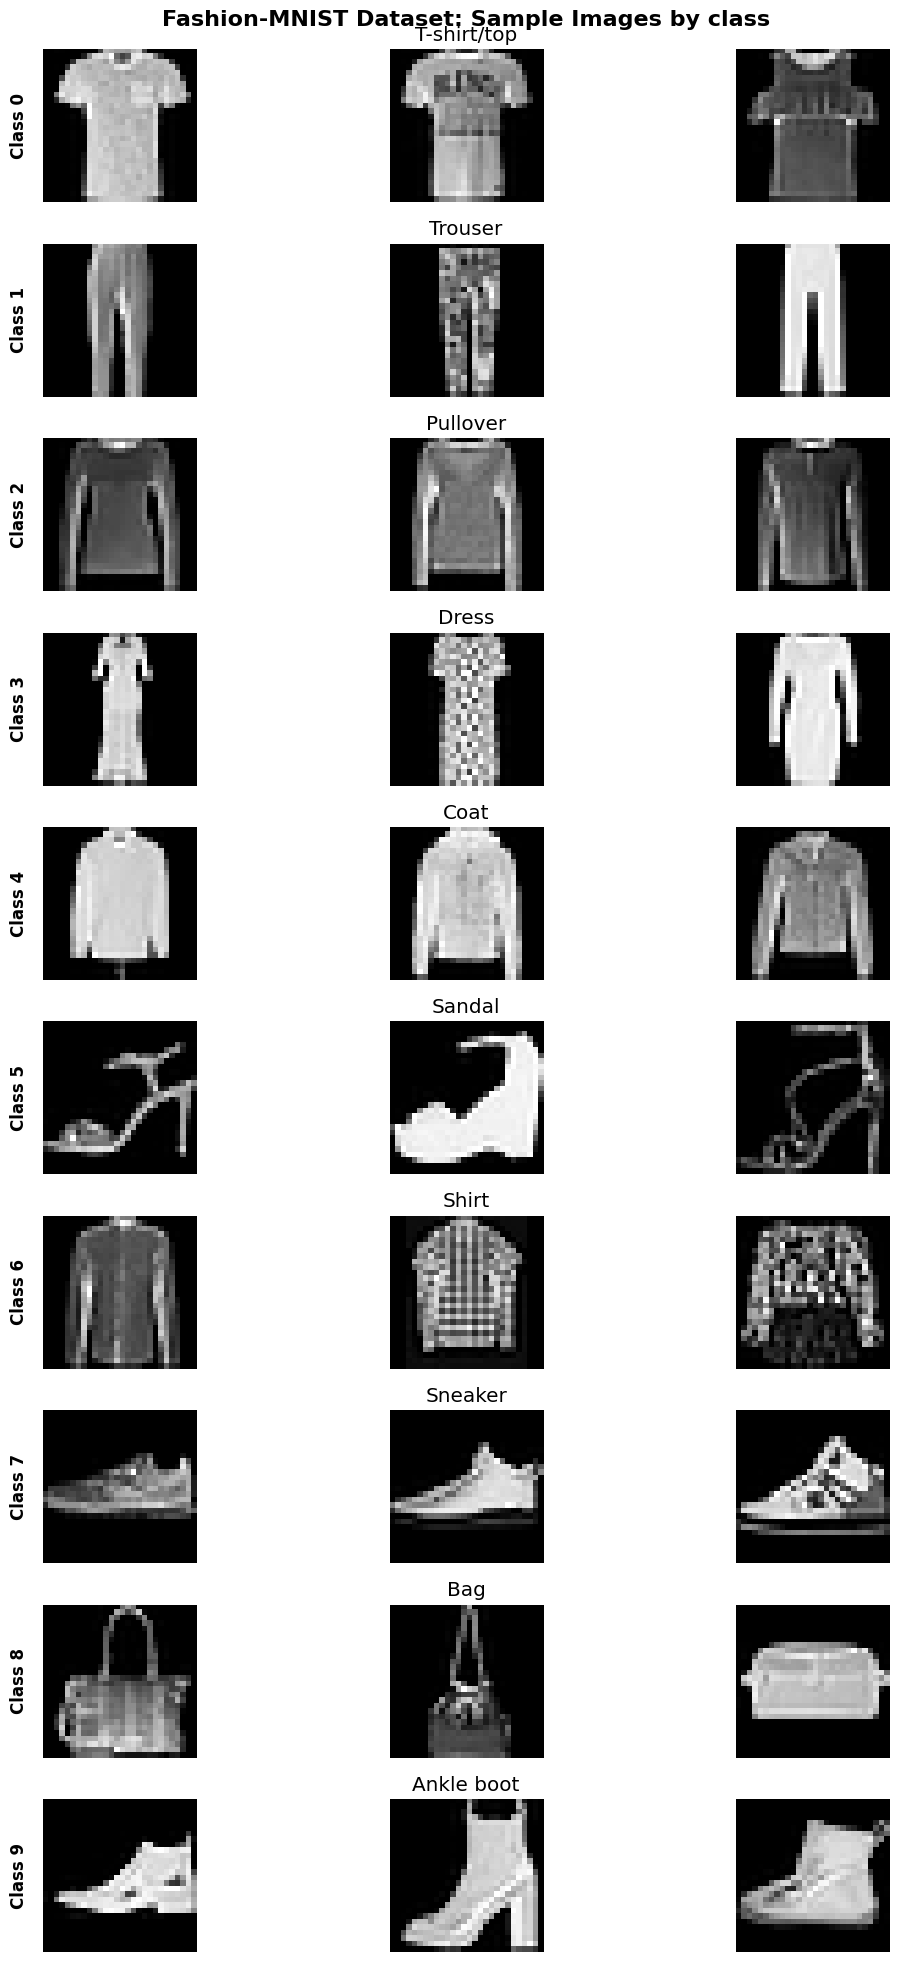

In [15]:
fig = plt.figure(figsize = (16,12))

print('-----visualization-----')


examples_per_class = 3
class_examples = {i:[] for i in range(10)}


for images,labels in train_loader:

  for i, label in enumerate(labels):
    class_idx = label.item()
    if len(class_examples[class_idx]) < examples_per_class:
      class_examples[class_idx].append(images[i])

  if all(len(examples) >= examples_per_class for examples in class_examples.values()):
    break





fig_examples,axes = plt.subplots(10,examples_per_class,figsize = (12,20))
fig_examples.suptitle('Fashion-MNIST Dataset: Sample Images by class',fontsize = 16,fontweight = 'bold')

for class_idx in range(10):
  for example_idx in range(examples_per_class):
    row,col = class_idx,example_idx
    image = class_examples[class_idx][example_idx].squeeze()

    axes[row,col].imshow(image,cmap = 'gray')
    axes[row,col].set_title(f'{class_names[class_idx]}' if col == 1 else '')
    axes[row,col].axis('off')
    if col == 0:
      axes[row, col].text(-0.1, 0.5, f'Class {class_idx}',
                          rotation=90, va='center', ha='right',
                          transform=axes[row, col].transAxes,
                          fontweight='bold', fontsize=12)



plt.tight_layout()
plt.show()

# Distribution Analysis

In [16]:
plt.figure(figsize = (15,10))

train_class_count = torch.zeros(10)

for _,labels in train_loader:
  for lable in labels:
    train_class_count[label.item()] +=1

print(train_class_count)

tensor([    0.,     0.,     0., 60000.,     0.,     0.,     0.,     0.,     0.,
            0.])


<Figure size 1500x1000 with 0 Axes>

In [17]:
test_class_count = torch.zeros(10)

for _,labels in test_loader:
  for label in labels:
    test_class_count[label.item()] +=1
print(test_class_count)

tensor([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])


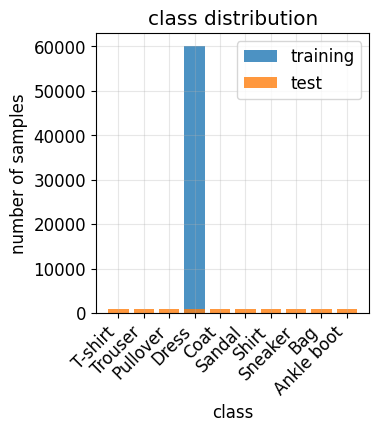

In [18]:
plt.subplot(2,3,1)

x_pos = np.arange(len(class_names))
plt.bar(x_pos,train_class_count,alpha = 0.8,label = 'training')
plt.bar(x_pos,test_class_count,alpha = 0.8,label = 'test')
plt.xlabel('class')
plt.ylabel('number of samples')
plt.title('class distribution')
plt.xticks(x_pos, [name.split('/')[0] for name in class_names], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)


# Pixel Intensity

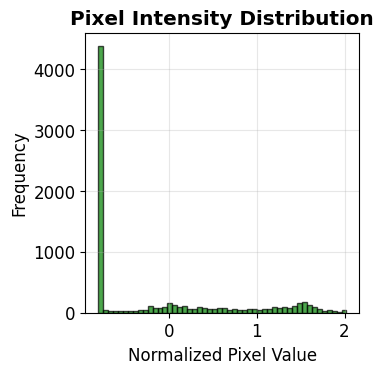

In [19]:
plt.subplot(2, 3, 2)
sample_images = torch.cat([class_examples[i][0] for i in range(10)])
pixel_values = sample_images.flatten().numpy()
plt.hist(pixel_values, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Normalized Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Intensity Distribution', fontweight='bold')
plt.grid(True, alpha=0.3)

# Model Architecture

In [20]:
class FashionMLP(nn.Module):
  def __init__(self,input_size = 784,hidden1_size = 128,hidden2_size=64,num_classes = 10):
    super(FashionMLP,self).__init__()

    self.flatten = nn.Flatten()
    # flatten because image has only 1 channel
    self.hidden1 = nn.Linear(input_size,hidden1_size)
    self.hidden2 = nn.Linear(hidden1_size,hidden2_size)
    self.output = nn.Linear(hidden2_size,num_classes)

    self.relu = nn.ReLU()

    self.dropout = nn.Dropout(p = 0.2)
    self.input_size = input_size
    self.hidden1_size = hidden1_size
    self.hidden2_size = hidden2_size
    self.num_classes = num_classes

  def forward(self,x):

    x  = self.flatten(x)

    x  = self.hidden1(x)
    x = self.relu(x)
    x = self.hidden2(x)
    x = self.relu(x)
    x = self.dropout(x)
    logits = self.output(x)

    return logits

  def get_model_info(self):

    total_param = sum(p.numel() for p in self.parameters())
    trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

    info = {
        'trainable parameters' : total_param,
        'total parameters':total_param
    }
    return info

model = FashionMLP().to(device)

print(model)


FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [21]:
print(model.get_model_info())

{'trainable parameters': 109386, 'total parameters': 109386}


# Training Model

In [22]:
Learning_rate = 0.001
num_epochs = 10

weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),
                       lr = Learning_rate,
                       weight_decay = weight_decay)


In [23]:
def model_accuracy(outputs,labels):
  _, predicted = torch.max(outputs.data,1)
  total = labels.size(0)
  correct = (predicted == labels).sum().item()
  return 100*correct/total

In [24]:
def train_model(model,dataloader,criterion,optimizer,device):
  model.train()

  total_loss = 0.0
  total_accuracy = 0.0
  num_batches = 0

  for batch_idx, (images,labels) in enumerate(dataloader):
    images,labels = images.to(device),labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs,labels)

    loss.backward()
    optimizer.step()

    accuracy = model_accuracy(outputs,labels)

    total_loss += loss.item()
    total_accuracy += accuracy
    num_batches +=1

    if (batch_idx + 1) % 200 == 0:
            print(f'   Batch [{batch_idx+1}/{len(dataloader)}] - '
                  f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')


    avg_loss = total_loss/num_batches
    avg_accuracy = total_accuracy/num_batches

    return avg_loss,avg_accuracy


In [25]:
def eval_model(model,dataloader,criterion,device):

  model.eval()

  total_loss = 0.0
  total_accuracy = 0.0
  num_batches = 0

  all_predictions = []
  all_labels = []

  with torch.no_grad():
    for images,labels in dataloader:
      images,labels = images.to(device),labels.to(device)

      outputs = model(images)

      loss = criterion(outputs,labels)

      accuracy = model_accuracy(outputs,labels)

      total_loss += loss.item()
      total_accuracy += accuracy
      num_batches +=1

      _,predicted = torch.max(outputs,1)

      all_predictions.extend(predicted.cpu().numpy())
  avg_loss = total_loss/num_batches
  avg_accuracy = total_accuracy/num_batches

  return avg_loss,avg_accuracy,all_predictions,all_labels







In [26]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Main training loop

In [28]:
import time

start_time = time.time()

for epoch in range(num_epochs):

  epoch_start_time = time.time()


  train_loss,train_accuracy = train_model(model,train_loader,criterion,optimizer,device)


  test_loss,test_accuracy,_,_ = eval_model(model,test_loader,criterion,device)


  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)
  test_losses.append(test_loss)
  test_accuracies.append(test_accuracy)

  epoch_time = time.time() - epoch_start_time

  print(f"   Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
  print(f"   Test Loss:  {test_loss:.4f} | Test Accuracy:  {test_accuracy:.2f}%")
  print(f"   Time: {epoch_time:.2f}s")

  if test_accuracy > 97.0:
    print('target accuracy reached')
    break

total_time = time.time()-start_time
print(f"Total training time: {total_time:.2f}s ({total_time/60:.1f} minutes)")
print(f"Final test accuracy: {test_accuracies[-1]:.2f}%")

   Train Loss: 1.9452 | Train Accuracy: 35.94%
   Test Loss:  1.8470 | Test Accuracy:  39.95%
   Time: 2.41s
   Train Loss: 1.9449 | Train Accuracy: 26.56%
   Test Loss:  1.7467 | Test Accuracy:  46.70%
   Time: 3.02s
   Train Loss: 1.6657 | Train Accuracy: 50.00%
   Test Loss:  1.6487 | Test Accuracy:  53.29%
   Time: 2.17s
   Train Loss: 1.6287 | Train Accuracy: 54.69%
   Test Loss:  1.5627 | Test Accuracy:  53.82%
   Time: 2.17s
   Train Loss: 1.6293 | Train Accuracy: 46.88%
   Test Loss:  1.4851 | Test Accuracy:  53.13%
   Time: 2.13s
   Train Loss: 1.6245 | Train Accuracy: 40.62%
   Test Loss:  1.4064 | Test Accuracy:  53.68%
   Time: 2.13s
   Train Loss: 1.4028 | Train Accuracy: 54.69%
   Test Loss:  1.3289 | Test Accuracy:  58.71%
   Time: 3.21s
   Train Loss: 1.2973 | Train Accuracy: 56.25%
   Test Loss:  1.2640 | Test Accuracy:  64.17%
   Time: 2.17s
   Train Loss: 1.3633 | Train Accuracy: 56.25%
   Test Loss:  1.2118 | Test Accuracy:  63.34%
   Time: 2.15s
   Train Loss: 1.10

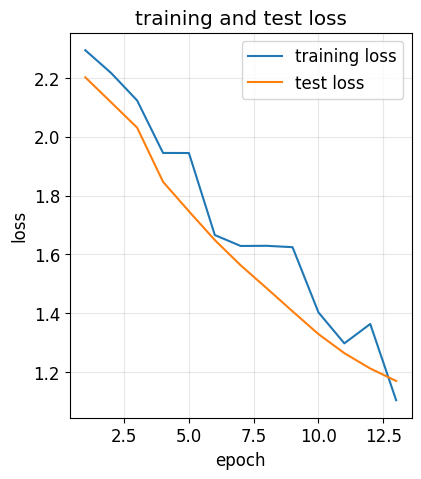

In [32]:
plt.figure(figsize = (15,5))

plt.subplot(1,3,1)

epoch_range = range(1,len(train_losses)+1)
plt.plot(epoch_range,train_losses,label = 'training loss')
plt.plot(epoch_range,test_losses,label = 'test loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and test loss')
plt.legend()
plt.grid(True,alpha = 0.3)

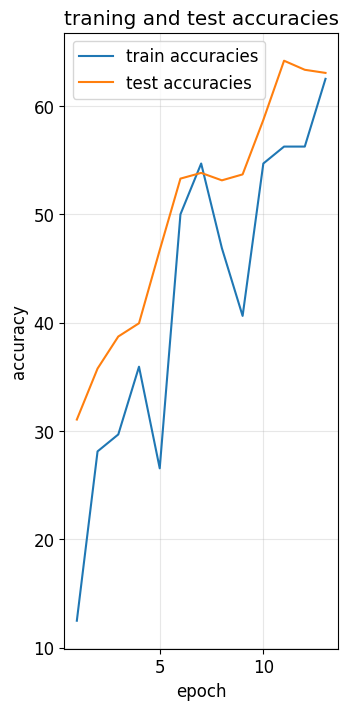

In [34]:
plt.subplot(1,3,2)

plt.plot(epoch_range,train_accuracies,label = 'train accuracies')
plt.plot(epoch_range,test_accuracies,label = 'test accuracies')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('traning and test accuracies')
plt.legend()
plt.grid(True,alpha = 0.3)

In [37]:
final_test_loss, final_test_accuracy, all_predictions, all_labels = eval_model(
    model, test_loader, criterion, device
)

predictions = np.array(all_predictions)
true_labels = np.array(all_labels)

print(classification_report(true_labels, predictions, target_names=class_names))


ValueError: Found input variables with inconsistent numbers of samples: [0, 10000]

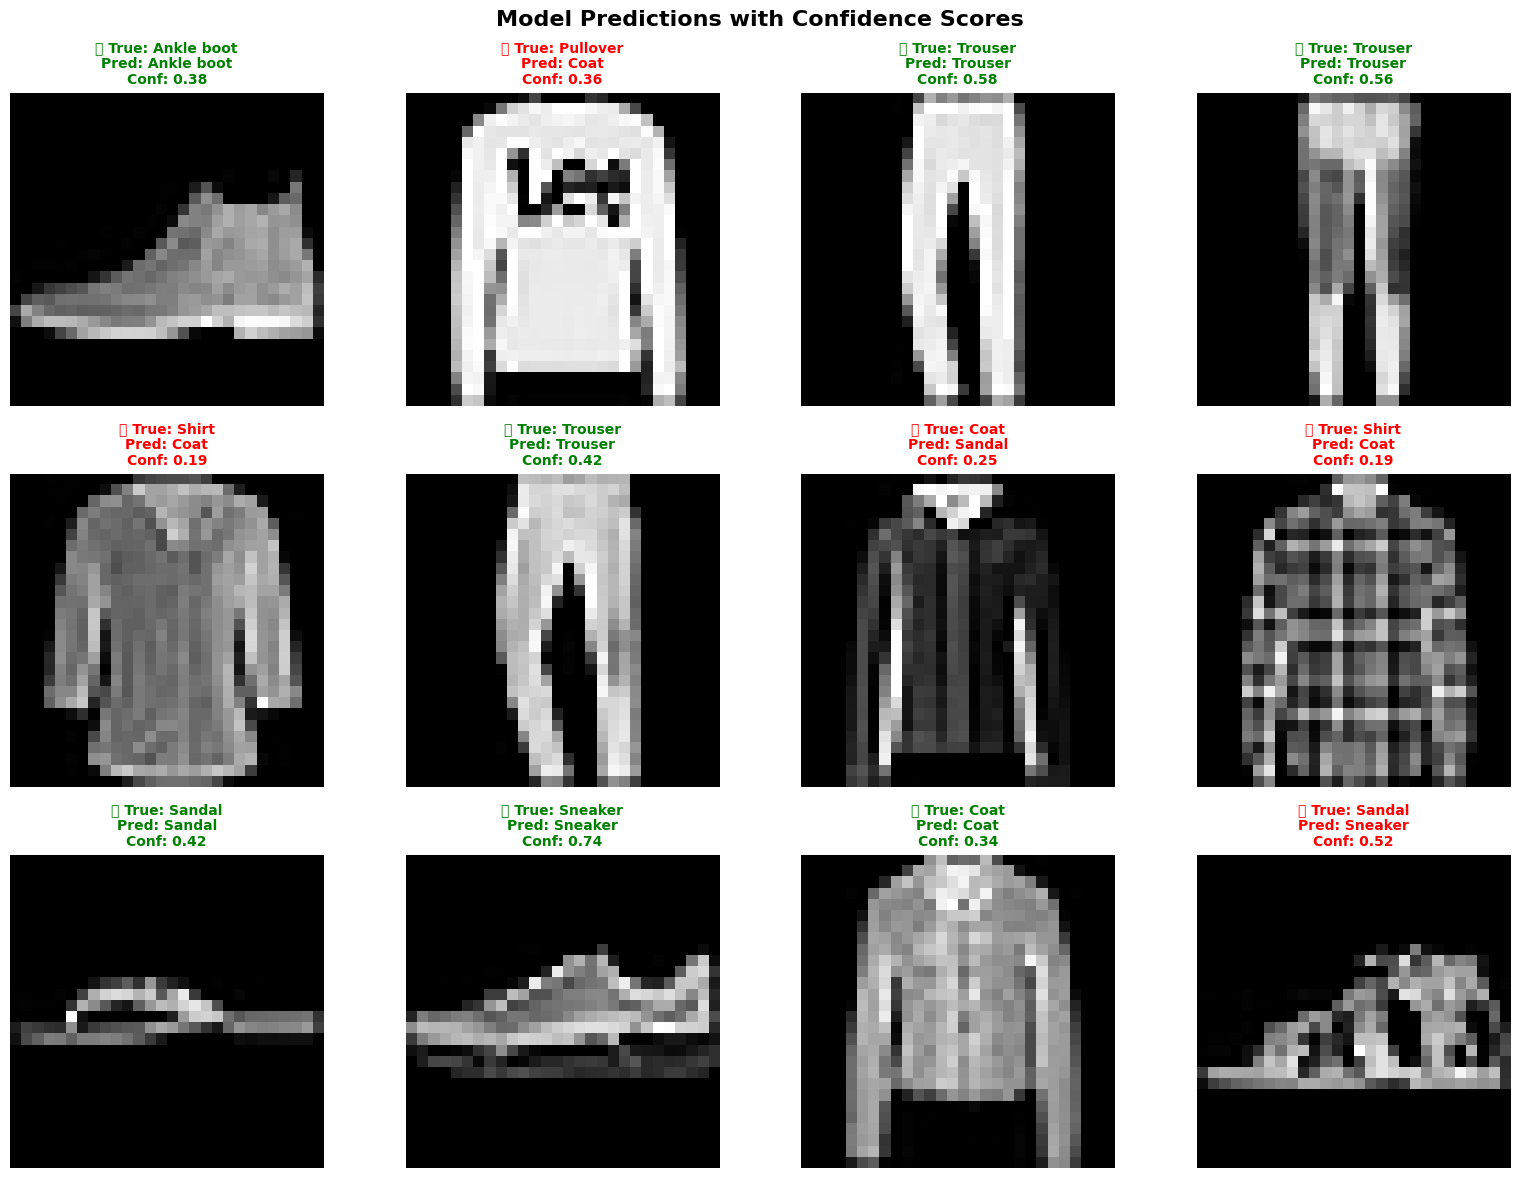

In [42]:
def visualize_predictions(model, dataloader, device, num_samples=12):
    model.eval()

    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, 1)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Model Predictions with Confidence Scores', fontsize=16, fontweight='bold')

    for i in range(num_samples):
        row, col = i // 4, i % 4

        image = images[i].cpu().squeeze()
        true_label = labels[i].cpu().item()
        pred_label = predictions[i].cpu().item()
        confidence = confidences[i].cpu().item()

        axes[row, col].imshow(image, cmap='gray')

        is_correct = pred_label == true_label
        color = 'green' if is_correct else 'red'
        symbol = '✅' if is_correct else '❌'

        title = f'{symbol} True: {class_names[true_label].split("/")[0]}\n'
        title += f'Pred: {class_names[pred_label].split("/")[0]}\n'
        title += f'Conf: {confidence:.2f}'

        axes[row, col].set_title(title, color=color, fontweight='bold', fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    return images, labels, predictions, confidences

sample_images, sample_labels, sample_predictions, sample_confidences = visualize_predictions(
    model, test_loader, device, num_samples=12)